Dataset Loaded Successfully
         Date      Time  Sale_Price  Units_Sold   Revenue
0  2026-01-01  13:23:15      716.85           6   4301.10
1  2026-01-02  09:14:20      756.78          20  15135.60
2  2026-01-03  19:35:58      853.96          33  28180.68
3  2026-01-04  12:08:04      787.09          24  18890.16
4  2026-01-05  10:44:25      830.39          27  22420.53

Data Types:
Date          datetime64[ns]
Time                  object
Sale_Price           float64
Units_Sold             int64
Revenue              float64
dtype: object

Dataset after setting Date as index:
                Time  Sale_Price  Units_Sold   Revenue
Date                                                  
2026-01-01  13:23:15      716.85           6   4301.10
2026-01-02  09:14:20      756.78          20  15135.60
2026-01-03  19:35:58      853.96          33  28180.68
2026-01-04  12:08:04      787.09          24  18890.16
2026-01-05  10:44:25      830.39          27  22420.53

First 10 Observations:
     

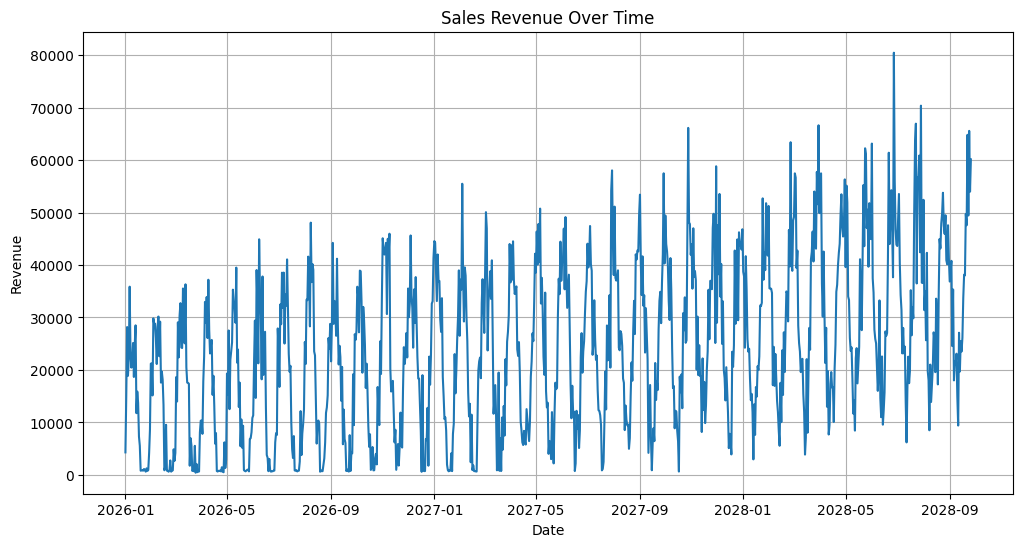


Sales Statistics
Mean Sales: 24166.17852
Minimum Sales: 424.22
Maximum Sales: 80446.88


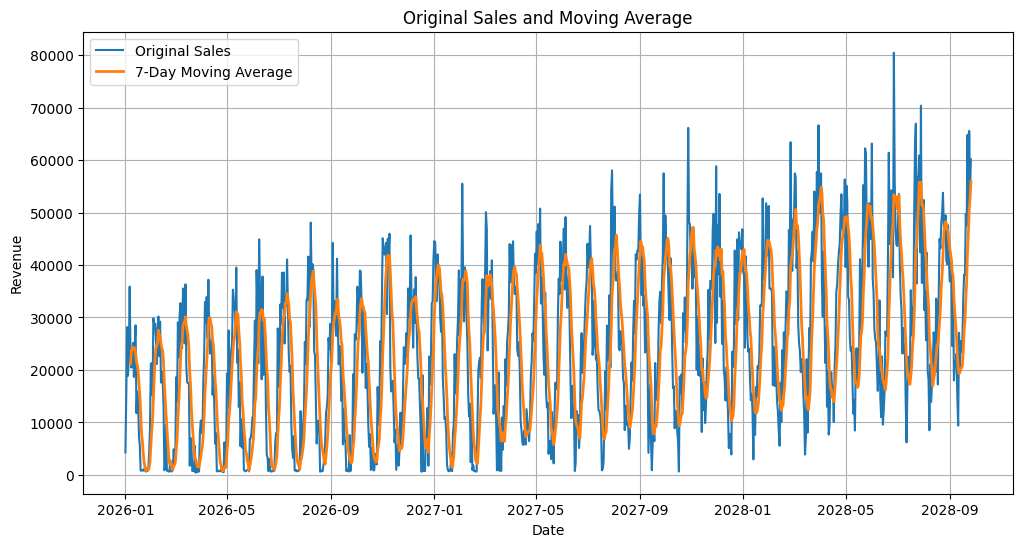


First 100 observations average: 14555.879
Last 100 observations average: 36896.8813
The dataset shows an INCREASING trend.

Predicted sales for next time period:
55885.24285714286


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------
# Q1. Load the time series dataset
# --------------------------------

df = pd.read_csv("sales_timeseries.csv")

print("Dataset Loaded Successfully")
print(df.head())

# Q2. Convert Date into DateTime

df["Date"] = pd.to_datetime(df["Date"])

print("\nData Types:")
print(df.dtypes)

# Q3. Set Date as the index

df.set_index("Date", inplace=True)

print("\nDataset after setting Date as index:")
print(df.head())

# Q4. Display first 10 observations

print("\nFirst 10 Observations:")
print(df.head(10))

# Q5. Plot the time series


plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Revenue"])

plt.title("Sales Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

# Q6. Mean, Minimum and Maximum

mean_sales = df["Revenue"].mean()
min_sales = df["Revenue"].min()
max_sales = df["Revenue"].max()

print("\nSales Statistics")
print("Mean Sales:", mean_sales)
print("Minimum Sales:", min_sales)
print("Maximum Sales:", max_sales)

# Q7. Original Sales + Moving Average

# 7-day moving average
df["Moving_Average"] = df["Revenue"].rolling(window=7).mean()

plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["Revenue"],
    label="Original Sales"
)

plt.plot(
    df.index,
    df["Moving_Average"],
    label="7-Day Moving Average",
    linewidth=2
)

plt.title("Original Sales and Moving Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

# Q9. Identify the trend

first_100_mean = df["Revenue"].iloc[:100].mean()
last_100_mean = df["Revenue"].iloc[-100:].mean()

print("\nFirst 100 observations average:", first_100_mean)
print("Last 100 observations average:", last_100_mean)

if last_100_mean > first_100_mean:
    print("The dataset shows an INCREASING trend.")
elif last_100_mean < first_100_mean:
    print("The dataset shows a DECREASING trend.")
else:
    print("The dataset shows an approximately STABLE trend.")


# Q10. Predict next sales value


prediction = df["Moving_Average"].iloc[-1]

print("\nPredicted sales for next time period:")
print(prediction)